In [ ]:
# AI in Healthcare - Lab Assignment 4
# Logistic Regression - Breast Cancer Wisconsin Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving breast+cancer+wisconsin+diagnostic.zip to breast+cancer+wisconsin+diagnostic (1).zip


In [ ]:
import zipfile
import os

zip_file = "breast+cancer+wisconsin+diagnostic (1).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("breast_cancer_dataset")

print("ZIP file extracted successfully!")
print("\nFiles inside the dataset folder:")

for file in os.listdir("breast_cancer_dataset"):
    print(file)

ZIP file extracted successfully!

Files inside the dataset folder:
wdbc.data
wdbc.names


In [ ]:
# Column names for the Wisconsin Diagnostic Breast Cancer dataset

columns = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

# Load the dataset
df = pd.read_csv(
    "breast_cancer_dataset/wdbc.data",
    header=None,
    names=columns
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Basic dataset information

print("Shape of dataset:", df.shape)

print("\nData Types:\n")
print(df.dtypes)

print("\nDataset Information:\n")
df.info()

Shape of dataset: (569, 32)

Data Types:

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_w

In [ ]:
# Summary statistics

summary = df.describe().T

# Add median
summary["Median"] = df.median(numeric_only=True)

summary = summary[[
    "mean",
    "Median",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
]]

summary.round(2)

,mean,Median,std,min,25%,50%,75%,max
id,30371831.43,906024.00,1.250206e+08,8670.00,869218.00,906024.00,8813129.00,9.113205e+08
radius_mean,14.13,13.37,3.520000e+00,6.98,11.70,13.37,15.78,2.811000e+01
texture_mean,19.29,18.84,4.300000e+00,9.71,16.17,18.84,21.80,3.928000e+01
perimeter_mean,91.97,86.24,2.430000e+01,43.79,75.17,86.24,104.10,1.885000e+02
area_mean,654.89,551.10,3.519100e+02,143.50,420.30,551.10,782.70,2.501000e+03
smoothness_mean,0.10,0.10,1.000000e-02,0.05,0.09,0.10,0.11,1.600000e-01
compactness_mean,0.10,0.09,5.000000e-02,0.02,0.06,0.09,0.13,3.500000e-01
concavity_mean,0.09,0.06,8.000000e-02,0.00,0.03,0.06,0.13,4.300000e-01
concave_points_mean,0.05,0.03,4.000000e-02,0.00,0.02,0.03,0.07,2.000000e-01
symmetry_mean,0.18,0.18,3.000000e-02,0.11,0.16,0.18,0.20,3.000000e-01


In [ ]:
# Check for missing values

print("Missing Values:\n")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

# Check for duplicate rows

duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Missing Values:

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 

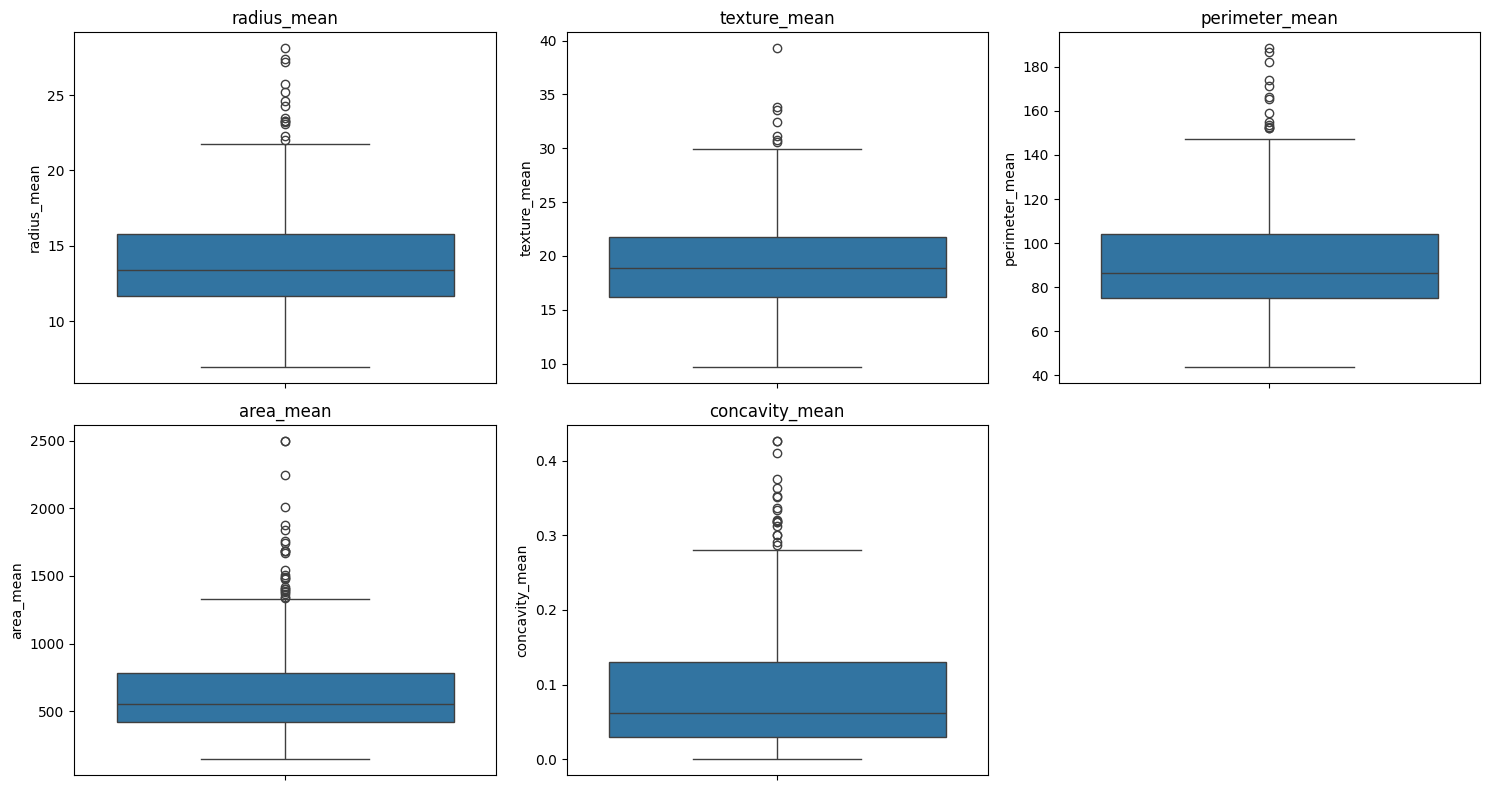

In [ ]:
# Check for outliers using box plots

features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concavity_mean"
]

plt.figure(figsize=(15, 8))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

In [ ]:
# Detect outliers using the IQR method

numeric_features = df.drop(columns=["id", "diagnosis"]).columns

outlier_counts = {}

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_counts[feature] = len(outliers)

outlier_table = pd.DataFrame(
    list(outlier_counts.items()),
    columns=["Feature", "Number of Outliers"]
)

outlier_table = outlier_table.sort_values(
    by="Number of Outliers",
    ascending=False
)

print("Outlier Detection using IQR:")
display(outlier_table)

Outlier Detection using IQR:


,Feature,Number of Outliers
13,area_se,65
10,radius_se,38
12,perimeter_se,38
23,area_worst,35
14,smoothness_se,30
19,fractal_dimension_se,28
15,compactness_se,28
18,symmetry_se,27
3,area_mean,25
29,fractal_dimension_worst,24


In [ ]:
# Handle outliers using IQR-based capping

# Separate features and target temporarily
X_outlier = df.drop(columns=["id", "diagnosis"]).copy()

# Apply IQR capping
for feature in X_outlier.columns:
    Q1 = X_outlier[feature].quantile(0.25)
    Q3 = X_outlier[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_outlier[feature] = X_outlier[feature].clip(
        lower=lower_bound,
        upper=upper_bound
    )

# Put the processed features back into the dataframe
df[X_outlier.columns] = X_outlier

print("Outliers handled using IQR-based capping.")
print("Extreme values have been capped at the lower and upper IQR boundaries.")

Outliers handled using IQR-based capping.
Extreme values have been capped at the lower and upper IQR boundaries.


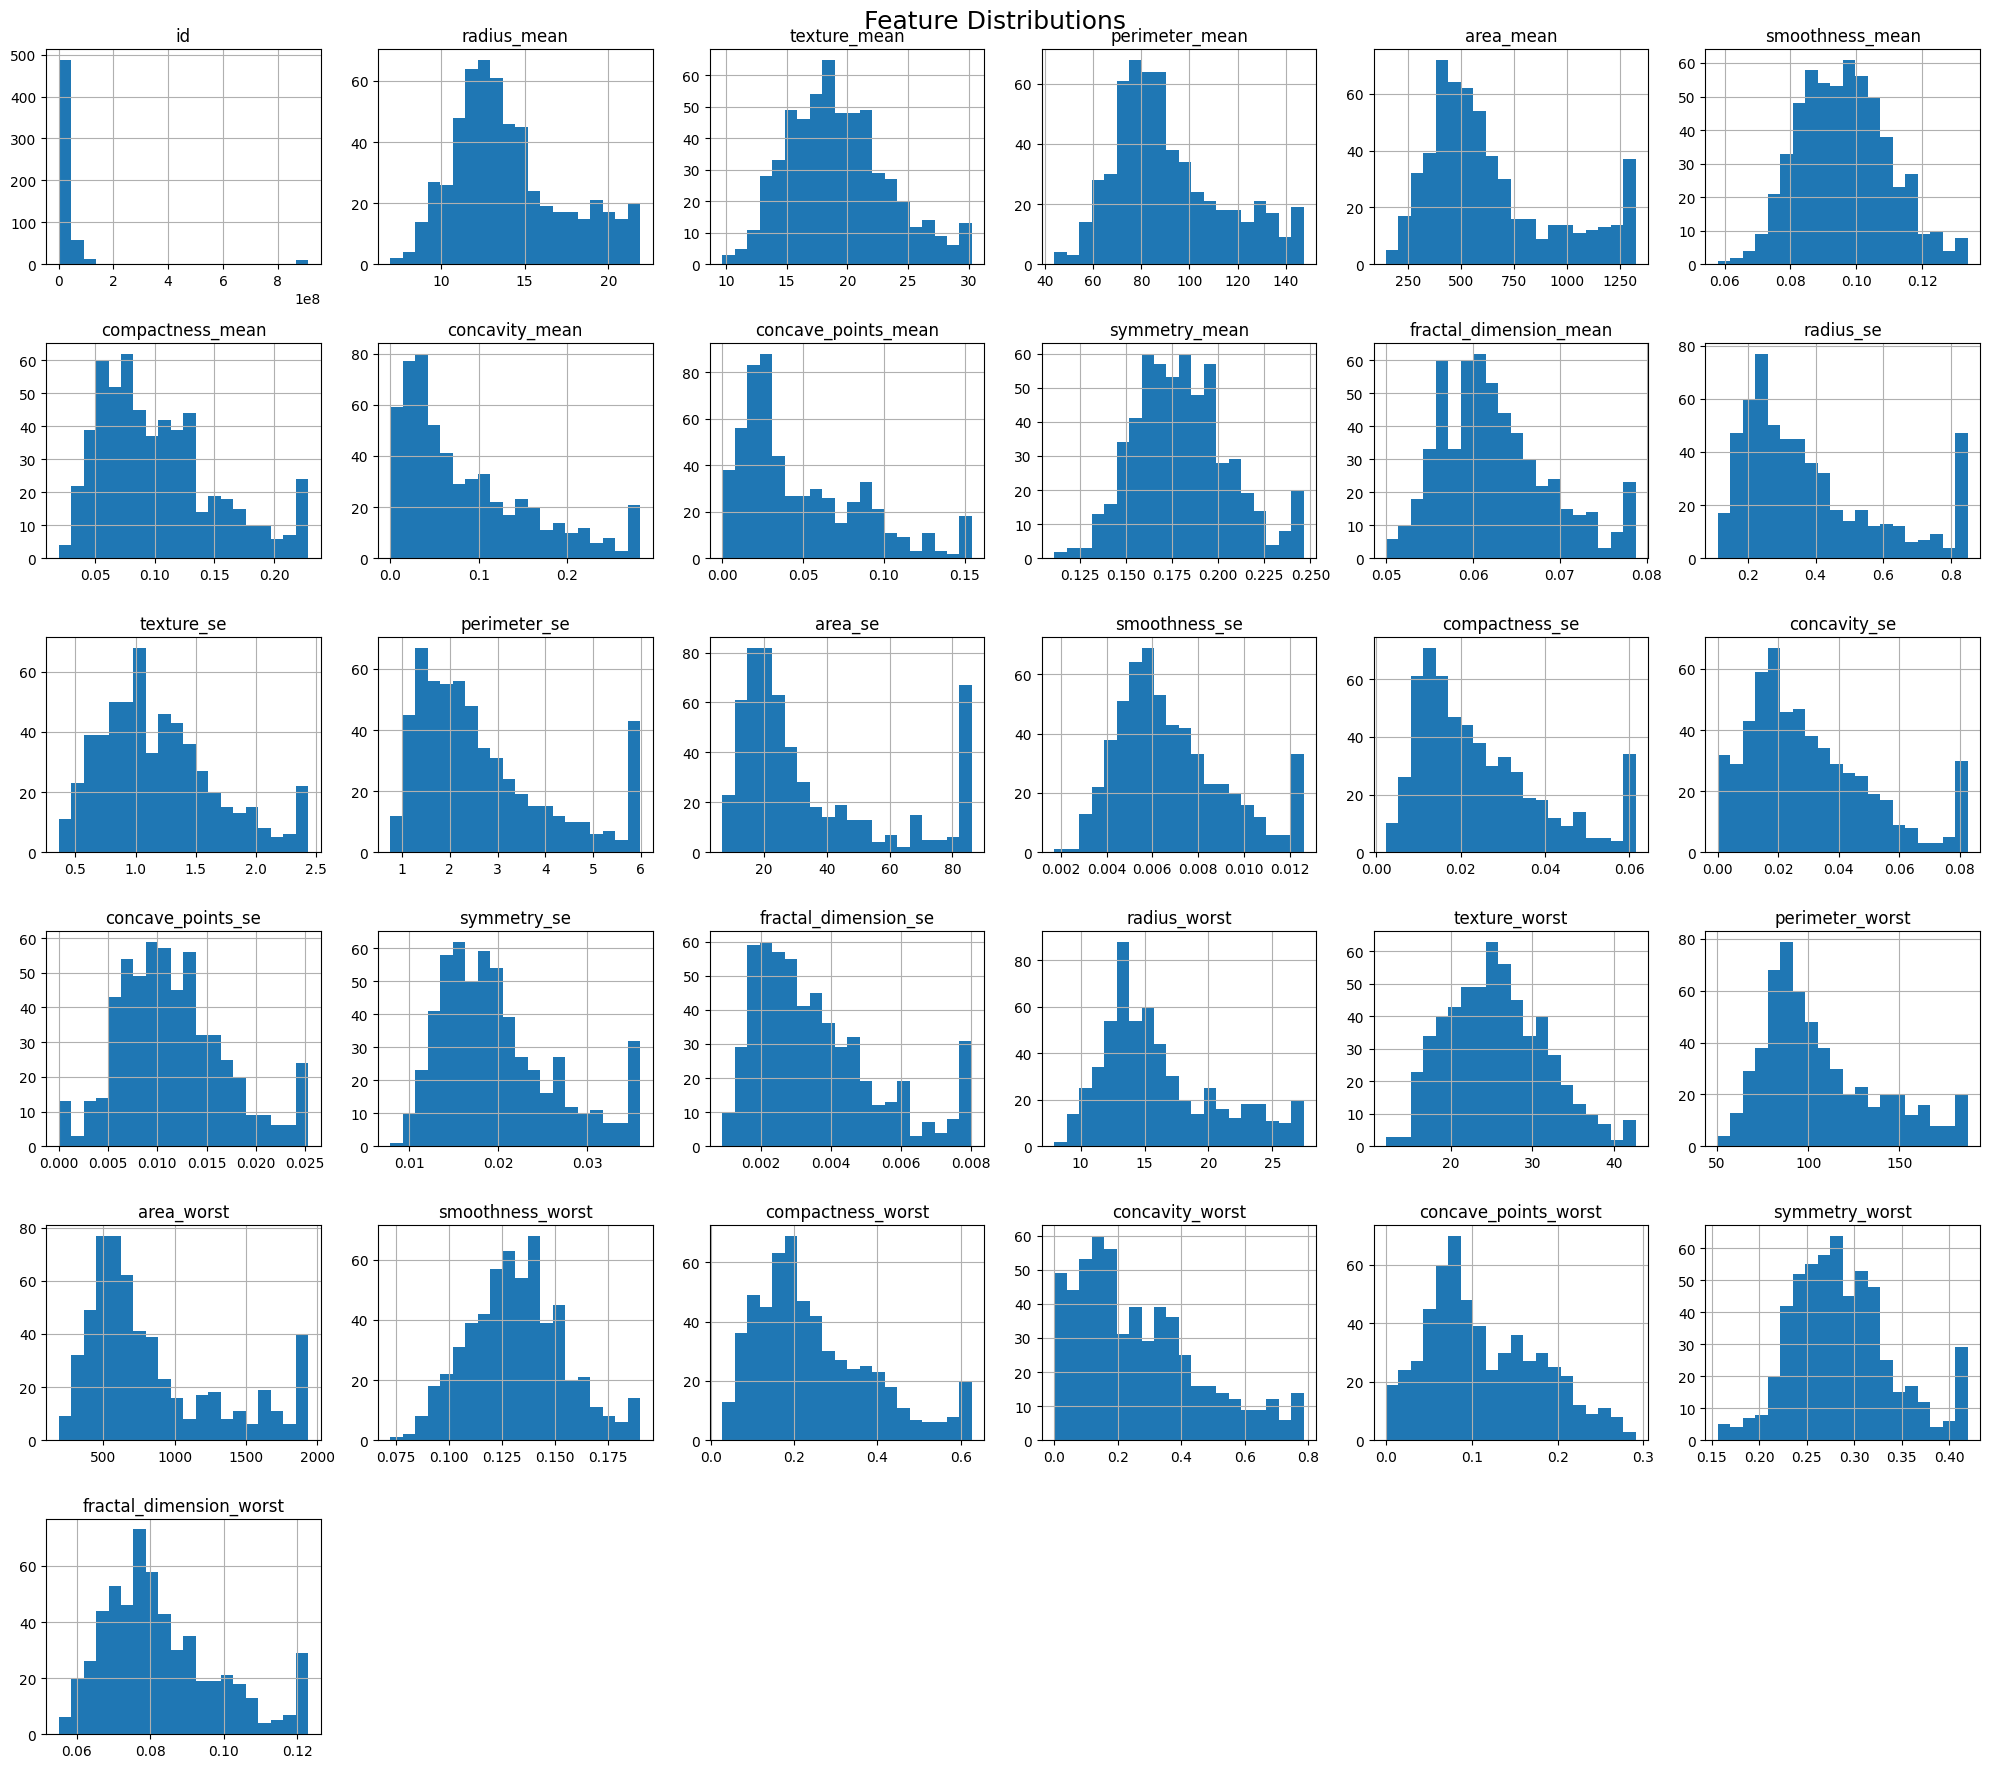

In [ ]:
# Histograms

df.hist(figsize=(20, 18), bins=20)

plt.suptitle("Feature Distributions", fontsize=18)
plt.tight_layout()
plt.show()

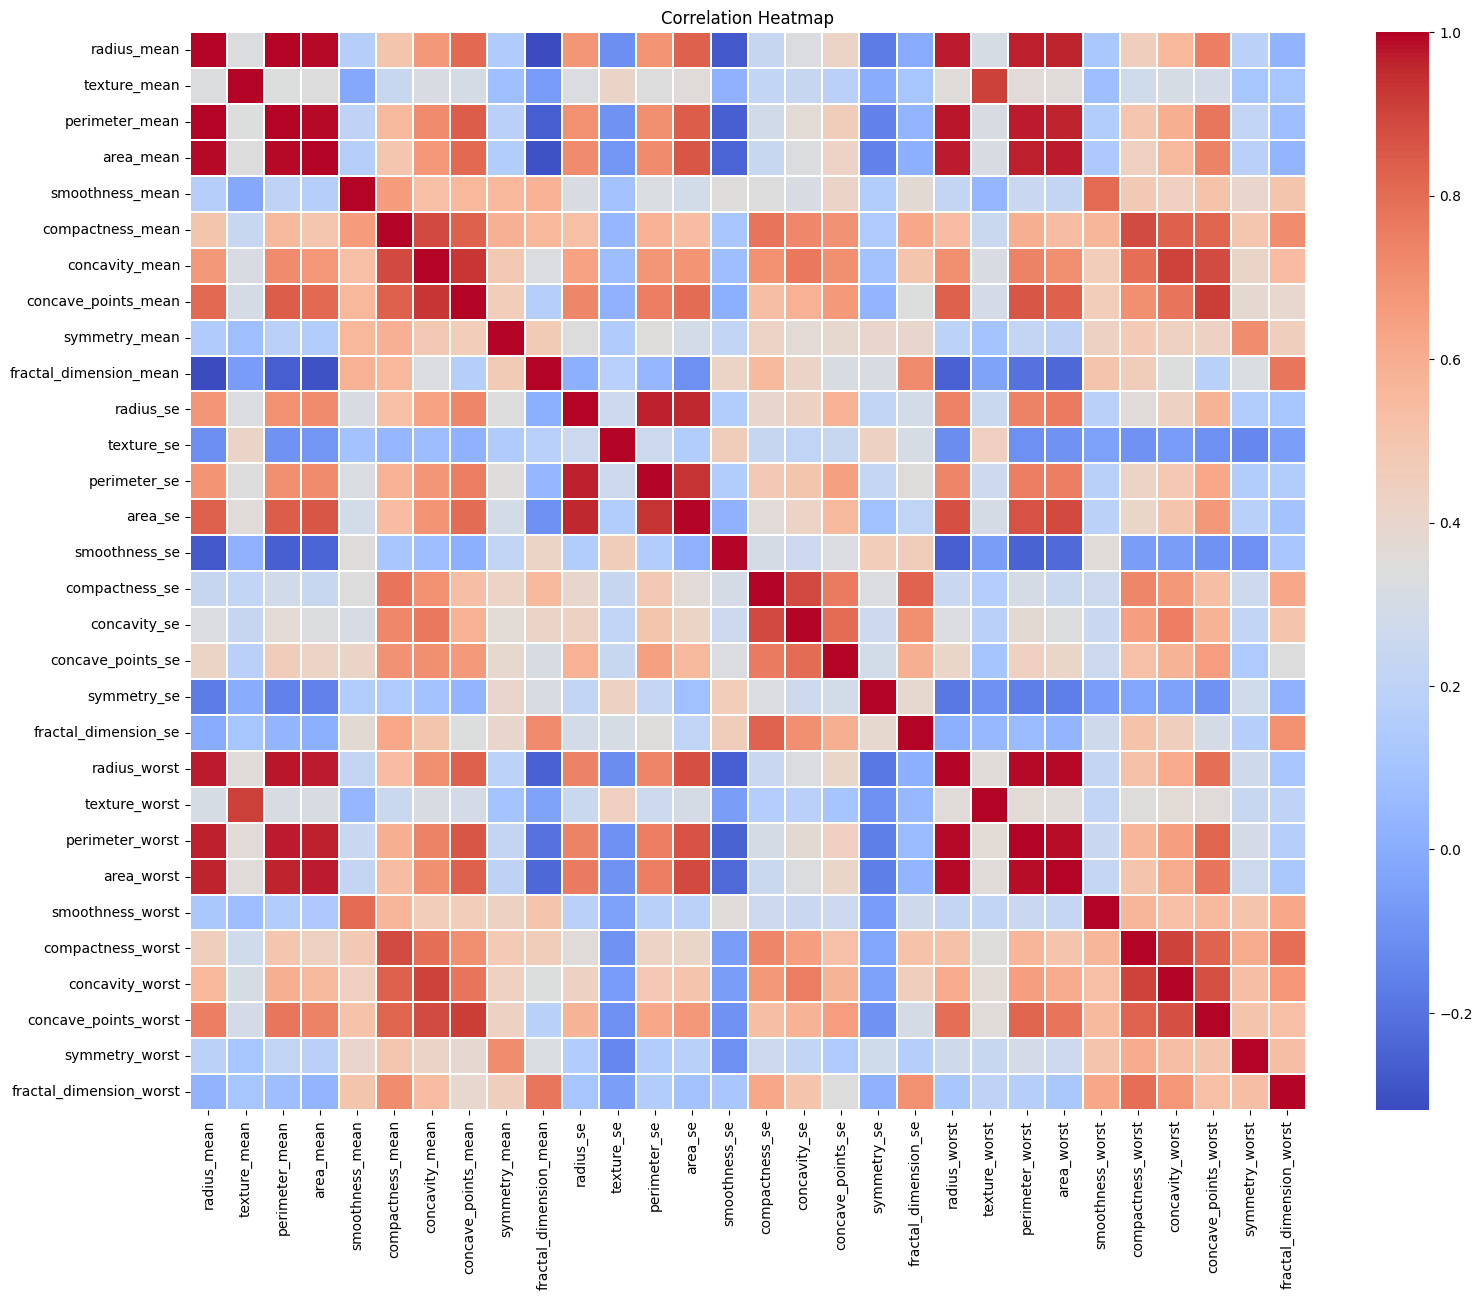

In [ ]:
# Correlation heatmap

plt.figure(figsize=(18, 14))

corr = df.drop(columns=["id"]).corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Correlation Heatmap")
plt.show()

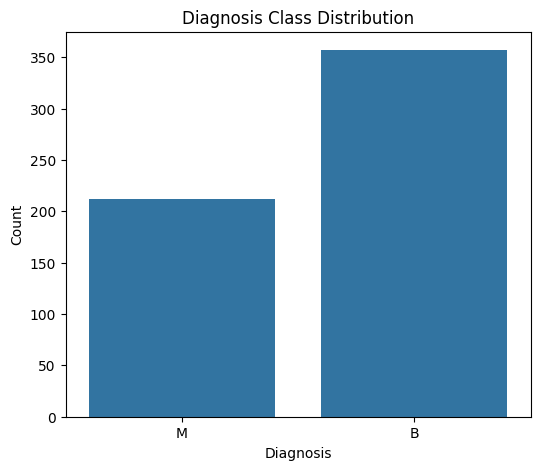

Class Counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Class Percentages:
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [ ]:
# Class distribution

plt.figure(figsize=(6, 5))

sns.countplot(x="diagnosis", data=df)

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

print("Class Counts:")
print(df["diagnosis"].value_counts())

print("\nClass Percentages:")
print(
    (df["diagnosis"].value_counts(normalize=True) * 100).round(2)
)

In [ ]:
# Discussion of class imbalance

class_counts = df["diagnosis"].value_counts()
class_percentages = df["diagnosis"].value_counts(normalize=True) * 100

print("Class Imbalance Analysis")
print("=" * 50)

print(f"Benign cases: {class_counts.get('B', 0)} "
      f"({class_percentages.get('B', 0):.2f}%)")

print(f"Malignant cases: {class_counts.get('M', 0)} "
      f"({class_percentages.get('M', 0):.2f}%)")

print("\nDiscussion:")
print("""
The dataset contains more benign cases than malignant cases,
so the two classes are not perfectly balanced.

Class imbalance can affect model training because a model may
perform well on the majority class while performing relatively
worse on the minority class.

In a medical diagnosis problem, this is important because
misclassifying a malignant case as benign can be more serious
than misclassifying a benign case as malignant.

Therefore, accuracy alone is not sufficient for evaluating the
model. Precision, recall, F1-score, confusion matrix and ROC-AUC
are also considered.

Stratified sampling is used during train-test splitting so that
the proportion of benign and malignant cases is maintained in
both the training and testing datasets.
""")

Class Imbalance Analysis
Benign cases: 357 (62.74%)
Malignant cases: 212 (37.26%)

Discussion:

The dataset contains more benign cases than malignant cases,
so the two classes are not perfectly balanced.

Class imbalance can affect model training because a model may
perform well on the majority class while performing relatively
worse on the minority class.

In a medical diagnosis problem, this is important because
misclassifying a malignant case as benign can be more serious
than misclassifying a benign case as malignant.

Therefore, accuracy alone is not sufficient for evaluating the
model. Precision, recall, F1-score, confusion matrix and ROC-AUC
are also considered.

Stratified sampling is used during train-test splitting so that
the proportion of benign and malignant cases is maintained in
both the training and testing datasets.



In [ ]:
# Encode diagnosis as binary

df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

print("Target encoding completed!")

print("\nDiagnosis values:")
print(df["diagnosis"].value_counts())

Target encoding completed!

Diagnosis values:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
# Separate features and target

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [ ]:
# Split dataset into training and testing sets
# Stratify ensures both sets maintain similar class proportions

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (455, 30)
Testing set: (114, 30)

Training class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Testing class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [ ]:
# Standardize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature standardization completed!
Scaled training data shape: (455, 30)
Scaled testing data shape: (114, 30)


In [ ]:
# Create and train Logistic Regression model

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test set

y_pred = model.predict(X_test_scaled)

# Probability of malignant class
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 actual values:")
print(y_test.values[:10])

print("\nFirst 10 predicted values:")
print(y_pred[:10])

Predictions generated successfully!

First 10 actual values:
[0 1 0 1 0 0 1 0 0 0]

First 10 predicted values:
[0 1 0 0 1 0 1 0 0 0]


In [ ]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Accuracy: 0.9649
Accuracy (%): 96.49 %


In [ ]:
# Classification report

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



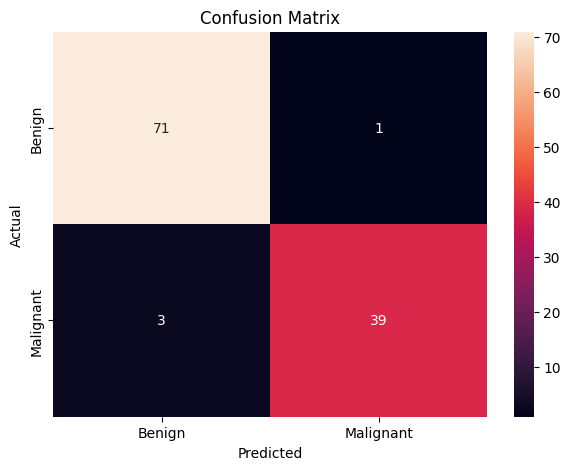

Confusion Matrix:
[[71  1]
 [ 3 39]]


In [ ]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print("Confusion Matrix:")
print(cm)

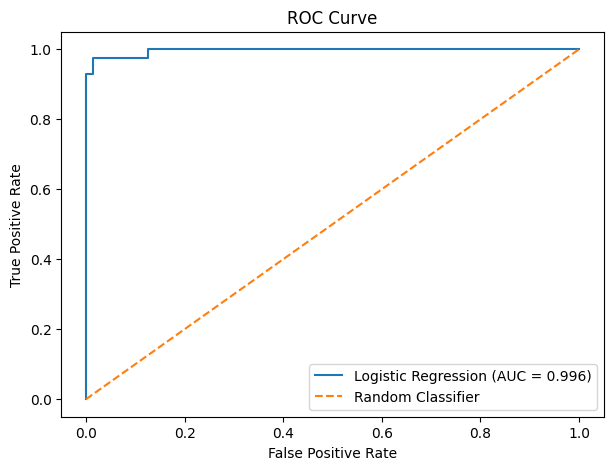

AUC Score: 0.9964


In [ ]:
# Calculate ROC curve and AUC

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score:", round(auc_score, 4))

In [ ]:
# Calculate all evaluation metrics

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

results["Score"] = results["Score"].round(4)

results

,Metric,Score
0,Accuracy,0.9649
1,Precision,0.9750
2,Recall,0.9286
3,F1-Score,0.9512
4,ROC-AUC,0.9964


In [ ]:
# Display the confusion matrix values clearly

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nDetailed values:")

print("True Negatives (TN):", cm[0, 0])
print("False Positives (FP):", cm[0, 1])
print("False Negatives (FN):", cm[1, 0])
print("True Positives (TP):", cm[1, 1])

Confusion Matrix:
[[71  1]
 [ 3 39]]

Detailed values:
True Negatives (TN): 71
False Positives (FP): 1
False Negatives (FN): 3
True Positives (TP): 39


In [ ]:
# Precision, Recall and F1-score for both classes

report = classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"],
    output_dict=True
)

metrics_both_classes = pd.DataFrame({
    "Class": ["Benign", "Malignant"],
    "Precision": [
        report["Benign"]["precision"],
        report["Malignant"]["precision"]
    ],
    "Recall": [
        report["Benign"]["recall"],
        report["Malignant"]["recall"]
    ],
    "F1-Score": [
        report["Benign"]["f1-score"],
        report["Malignant"]["f1-score"]
    ]
})

metrics_both_classes.round(4)

,Class,Precision,Recall,F1-Score
0,Benign,0.9595,0.9861,0.9726
1,Malignant,0.9750,0.9286,0.9512


## Interpretation and Conclusion

The Logistic Regression model was trained to classify breast cancer
cases as benign or malignant.

Accuracy shows the overall proportion of correctly classified cases.
Precision indicates how many of the cases predicted as malignant were
actually malignant, while recall indicates how many of the actual
malignant cases were correctly identified. The F1-score provides a
balance between precision and recall. The confusion matrix shows the
numbers of true positive, true negative, false positive, and false
negative predictions. The ROC curve and AUC score describe the model's
ability to distinguish between benign and malignant cases.

In a medical diagnosis problem, false-negative predictions are
particularly important because a malignant case incorrectly classified
as benign could delay further medical evaluation. Therefore, recall
for the malignant class should be carefully considered along with
other evaluation metrics.

Overall, the results demonstrate how Logistic Regression can be used
for binary classification of breast cancer cases. However, the model
should be treated as a decision-support tool and not as a replacement
for professional medical diagnosis.